In [2]:
%pip install numpy==1.24.3 pandas==2.0.3 matplotlib==3.7.1 seaborn==0.12.2

  Using cached matplotlib-3.7.1-cp311-cp311-win_amd64.whl.metadata (5.8 kB)
  Using cached seaborn-0.12.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
  Using cached contourpy-1.3.2-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
Using cached matplotlib-3.7.1-cp311-cp311-win_amd64.whl (7.6 MB)
Using cached seaborn-0.12.2-py3-none-any.whl (293 kB)
Using cached contourpy-1.3.2-cp311-cp311-win_amd64.whl (222 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv('shoe_sales.csv')
df.head()

,date,brand,sold_qty
0,9/1/2023,Nike,24.0
1,9/1/2023,Adidas,14.0
2,9/2/2023,Nike,21.0
3,9/2/2023,Adidas,12.0
4,9/3/2023,Nike,18.0


In [7]:
df.shape


(60, 3)

In [8]:
df.describe()

,sold_qty
count,58.000000
mean,27.482759
std,88.519844
min,7.000000
25%,12.250000
50%,16.000000
75%,19.750000
max,689.000000


In [9]:
df[df.sold_qty<12.250000].shape

(15, 3)

In [10]:
15/60

0.25

In [12]:
df_nike = df[df.brand=='Nike']
df_nike.head()

,date,brand,sold_qty
0,9/1/2023,Nike,24.0
2,9/2/2023,Nike,21.0
4,9/3/2023,Nike,18.0
6,9/4/2023,Nike,22.0
8,9/5/2023,Nike,20.0


In [13]:
df.describe()

,sold_qty
count,58.000000
mean,27.482759
std,88.519844
min,7.000000
25%,12.250000
50%,16.000000
75%,19.750000
max,689.000000


In [16]:
round(df_nike.sold_qty.median())

20

In [18]:
df_nike.isnull()

,date,brand,sold_qty
0,False,False,False
2,False,False,False
4,False,False,False
6,False,False,False
8,False,False,False
10,False,False,False
12,False,False,False
14,False,False,False
16,False,False,False
18,False,False,False


In [19]:
df_nike[df_nike.sold_qty.isnull()]

,date,brand,sold_qty
32,9/17/2023,Nike,NaN
48,9/25/2023,Nike,NaN


In [20]:
df_nike.sold_qty.fillna(round(df_nike.sold_qty.median()), inplace=True)

C:\Users\hapatil\AppData\Local\Temp\ipykernel_25256\513829845.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nike.sold_qty.fillna(round(df_nike.sold_qty.median()), inplace=True)


In [21]:
df_nike[df_nike.sold_qty.isnull()]


,date,brand,sold_qty


In [22]:
df_nike.loc[[32,48]]

,date,brand,sold_qty
32,9/17/2023,Nike,20.0
48,9/25/2023,Nike,20.0


In [24]:
df_adidas = df[df.brand=='Adidas']
df_adidas.head()
df_adidas.shape

(30, 3)

In [25]:
df_adidas.describe()

,sold_qty
count,30.000000
mean,34.800000
std,123.602366
min,7.000000
25%,10.000000
50%,12.500000
75%,15.000000
max,689.000000


In [26]:
df_adidas.sold_qty.sum()

1044.0

In [27]:
df_adidas.sold_qty.median()

12.5

In [29]:
df_adidas.sold_qty.quantile([0.95])

0.95    18.55
Name: sold_qty, dtype: float64

In [28]:
df_adidas[df_adidas.sold_qty>18.55]

,date,brand,sold_qty
23,9/12/2023,Adidas,689.0
39,9/20/2023,Adidas,19.0


In [33]:
# plot nike and adidas in line chart to find outliers
def plot_qty():
    plt.figure(figsize=(10,6))
    dates = df_nike['date']
    plt.plot(dates, df_nike.sold_qty, label='Nike')
    plt.plot(dates, df_adidas.sold_qty, label='Adidas')
    plt.xlabel('Date')
    plt.ylabel('Sold Quantity')
    plt.title('Sold Quantity of Nike and Adidas over Time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


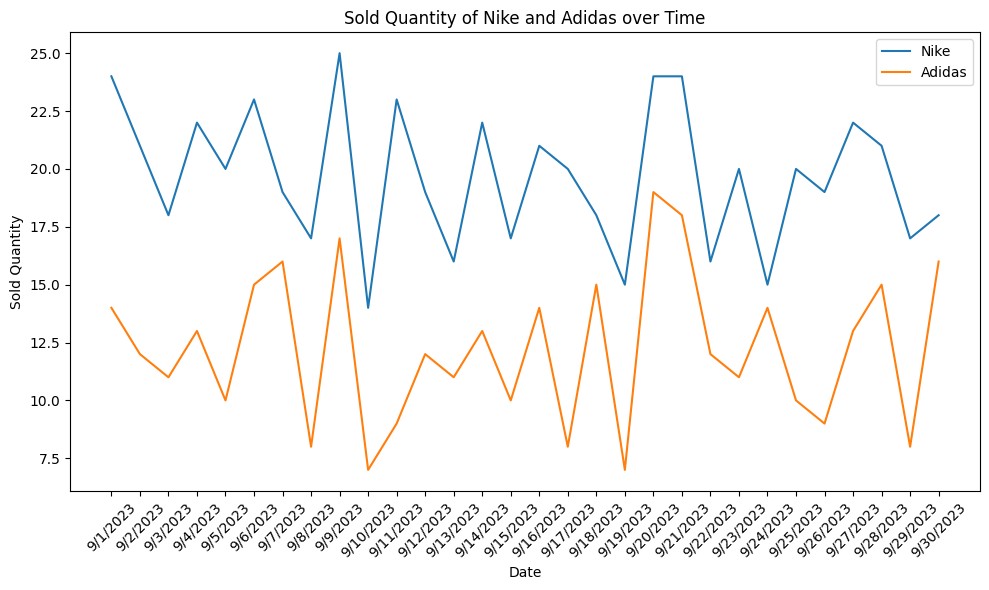

In [40]:
plot_qty()

In [38]:
val = round(df_adidas.sold_qty.median())
df_adidas.sold_qty.median()

12.0

In [39]:
df_adidas.sold_qty.replace(689,val, inplace=True)

C:\Users\hapatil\AppData\Local\Temp\ipykernel_25256\3598278759.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_adidas.sold_qty.replace(689,val, inplace=True)
